In [10]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [11]:
import os
os.listdir('/kaggle/input/competitions/digit-recognizer')

['sample_submission.csv', 'train.csv', 'test.csv']

In [12]:
data = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [13]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
data = np.array(data)
# chia dataset nếu dùng sklearn sẽ có train_test_split, làm chay thì ko
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T # chuyển vị hàng thành cột, lấy 1k làm ví dụ
Y_dev = data_dev[0] # đây là label
X_dev = data_dev[1:n] / 255.0 # còn đây là feature, chia để normalize pixel về 0-1

data_train = data[1000:m].T # Phần còn lại của dataset
Y_train = data_train[0]
X_train = data_train[1:n] / 255.0

In [15]:
Y_train

array([7, 8, 7, ..., 0, 6, 5])

In [16]:
X_train[:,0].shape

(784,)

In [17]:
def init_params(layer_dims, seed=42):  # initializer tổng quát
    np.random.seed(seed)
    params = {}
    L = len(layer_dims) - 1

    for l in range(1, L + 1):
        in_dim = layer_dims[l - 1]
        out_dim = layer_dims[l]
        # He init giúp mạng ReLU học ổn định hơn random thường
        params[f"W{l}"] = np.random.randn(out_dim, in_dim) * np.sqrt(2.0 / in_dim)
        params[f"b{l}"] = np.zeros((out_dim, 1))

    return params

In [18]:
def Relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def foward_prop(X, params):
    caches = []
    A = X
    L = len(params) // 2
    
    # Hidden layers: ReLU
    for l in range(1, L):
        W = params[f"W{l}"]
        b = params[f"b{l}"]
        Z = W.dot(A) + b
        A_next = Relu(Z)
        caches.append((A, Z, W, b))
        A = A_next

    # Output layer: Softmax
    W = params[f"W{L}"]
    b = params[f"b{L}"]
    ZL = W.dot(A) + b
    AL = softmax(ZL)
    caches.append((A, ZL, W, b))

    return AL, caches

def onehot(Y, num_classes=10):
    one_hot_Y = np.zeros((num_classes, Y.size))
    one_hot_Y[Y, np.arange(Y.size)] = 1
    return one_hot_Y

def deriv_relu(Z):
    # vì cách hoạt động của ReLU là mọi phần tử đều là 0 hoặc >= 0
    # n+332ên nếu Z > 0 thì là true = 1, false = 0
    # còn thắc mắc tại sao đạo hàm mà lại chỉ đi check thế này
    # thì học lại giải tích
    return (Z > 0).astype(float)

def compute_loss(AL, Y):
    m = Y.size
    one_hot_Y = onehot(Y, AL.shape[0])
    eps = 1e-12
    return -(1 / m) * np.sum(one_hot_Y * np.log(AL + eps))


def back_prop(AL, caches, Y):
    grads = {}
    L = len(caches)
    m = Y.size
    one_hot_Y = onehot(Y, AL.shape[0])

    # Output layer
    A_prev, _, W, _ = caches[-1]
    dZ = AL - one_hot_Y
    grads[f"dW{L}"] = (1 / m) * dZ.dot(A_prev.T)
    grads[f"db{L}"] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = W.T.dot(dZ)

    # Hidden layers (reverse)
    for l in range(L - 1, 0, -1):
        A_prev, Z, W, _ = caches[l - 1]
        dZ = dA_prev * deriv_relu(Z)
        grads[f"dW{l}"] = (1 / m) * dZ.dot(A_prev.T)
        grads[f"db{l}"] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
        dA_prev = W.T.dot(dZ)

    return grads

def update_params(params, grads, learning_rate):
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f"W{l}"] = params[f"W{l}"] - learning_rate * grads[f"dW{l}"]
        params[f"b{l}"] = params[f"b{l}"] - learning_rate * grads[f"db{l}"]
    return params


In [19]:
def get_predict(AL):
    return np.argmax(AL, 0)


def get_accu(predict, Y):
    return np.sum(predict == Y) / Y.size


def gradient_descent(X, Y, iter, learning_rate, layer_dims):
    params = init_params(layer_dims)

    for i in range(iter):
        AL, caches = foward_prop(X, params)
        grads = back_prop(AL, caches, Y)
        params = update_params(params, grads, learning_rate)

        if i % 10 == 0:
            print("Iteration:", i)
            print("Loss:", round(compute_loss(AL, Y), 6))
            print("Accuracy:", round(get_accu(get_predict(AL), Y), 6))

    return params

In [20]:
layer_dims = [784, 128, 64, 10]
params = gradient_descent(X_train, Y_train, 500, 0.05, layer_dims)

Iteration: 0
Loss: 2.389652
Accuracy: 0.070902
Iteration: 10
Loss: 2.040683
Accuracy: 0.395366
Iteration: 20
Loss: 1.718848
Accuracy: 0.601244
Iteration: 30
Loss: 1.387082
Accuracy: 0.702463
Iteration: 40
Loss: 1.105565
Accuracy: 0.762268
Iteration: 50
Loss: 0.903052
Accuracy: 0.798976
Iteration: 60
Loss: 0.767016
Accuracy: 0.822317
Iteration: 70
Loss: 0.674341
Accuracy: 0.837951
Iteration: 80
Loss: 0.608503
Accuracy: 0.850049
Iteration: 90
Loss: 0.559741
Accuracy: 0.859439
Iteration: 100
Loss: 0.522277
Accuracy: 0.866293
Iteration: 110
Loss: 0.492594
Accuracy: 0.872122
Iteration: 120
Loss: 0.468507
Accuracy: 0.877317
Iteration: 130
Loss: 0.44849
Accuracy: 0.881634
Iteration: 140
Loss: 0.431588
Accuracy: 0.885537
Iteration: 150
Loss: 0.417083
Accuracy: 0.888537
Iteration: 160
Loss: 0.404471
Accuracy: 0.891488
Iteration: 170
Loss: 0.393365
Accuracy: 0.893561
Iteration: 180
Loss: 0.38349
Accuracy: 0.895707
Iteration: 190
Loss: 0.37463
Accuracy: 0.897341
Iteration: 200
Loss: 0.36662
Accur

In [21]:
def make_predictions(X, params):
    AL, _ = foward_prop(X, params)
    predictions = get_predict(AL)
    return predictions


def test_prediction(index, params):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], params)
    label = Y_train[index]
    print("Prediction:", prediction)
    print("Label:", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction: [7]
Label: 7


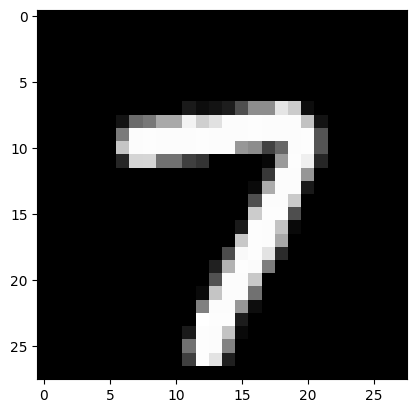

Prediction: [8]
Label: 8


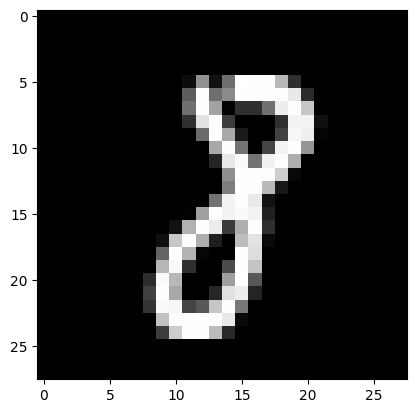

Prediction: [7]
Label: 7


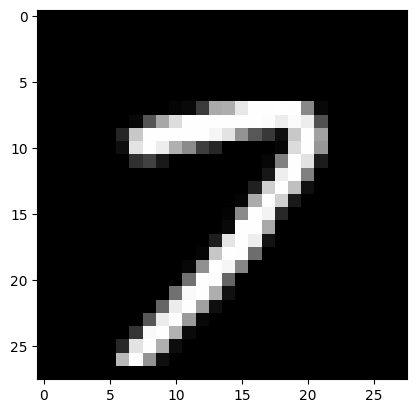

Prediction: [9]
Label: 9


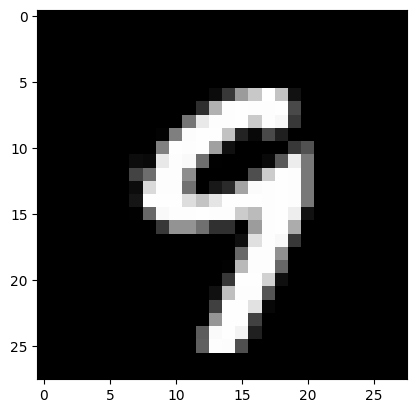

In [22]:
test_prediction(0, params)
test_prediction(1, params)
test_prediction(2, params)
test_prediction(3, params)

Image number: 25522
Prediction: [7]
Label: 7


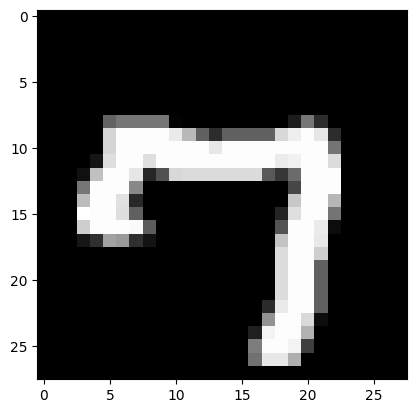

In [23]:
import random
num = random.randint(0, X_train.shape[1] - 1) # 34683

print("Image number:", num)
test_prediction(num, params)

In [24]:
# Thử lại với dev (test) dataset
dev_predictions = make_predictions(X_dev, params)
get_accu(dev_predictions, Y_dev)

np.float64(0.921)

Vẫn đc 92.1% -> Tương đối khớp với độ chính xác ban đầu

In [25]:
import pickle

# Lưu mô hình đã train (dict params + kiến trúc layer)
model_bundle = {
    "params": params,
    "layer_dims": layer_dims,
}

out_path = "multilayer_model.pkl"
with open(out_path, "wb") as f:
    pickle.dump(model_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved to", out_path)

# (Tuỳ chọn) Load lại để kiểm tra
with open(out_path, "rb") as f:
    loaded = pickle.load(f)
assert "params" in loaded and "layer_dims" in loaded
print("layer_dims:", loaded["layer_dims"])
print("params keys:", list(loaded["params"].keys()))


Saved to multilayer_model.pkl
layer_dims: [784, 128, 64, 10]
params keys: ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']
